# Data Transformations

> Functions for getting, splitting, and labeling data

In [ ]:
#| default_exp data.tfms

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import os
import random
from inspect import signature, _empty

# =================================
# Third-party scientific stack
# =================================
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as OmeTiffWriter

# =================================
# PyTorch
# =================================
from torch.utils.data import DataLoader as torchDataLoader

# =================================
# fastai
# =================================
from fastai.vision.all import get_grid

# =================================
# MONAI
# =================================
from monai.inferers import SlidingWindowSplitter, Splitter

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, _sanitize
from bioMONAI.data.core import *
from bioMONAI.data.load import *

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data getters

Functions to retrieve specific data components are provided, aiding in the organization and preprocessing of datasets.

In [ ]:
#| export
from fastai.vision.all import get_image_files
from typing import Callable
import re
from glob import glob as glob_expand

In [ ]:
#| export
def _glob_to_regex(pattern: str) -> str:
    pattern = re.escape(pattern)
    pattern = pattern.replace(r"\*", ".*")
    pattern = pattern.replace(r"\?", ".")
    pattern = pattern.replace(r"\[", "[")
    pattern = pattern.replace(r"\]", "]")
    return f"^{pattern}$"


def _build_filename_predicate(
    filename_filter: str|re.Pattern|Callable[[str], bool]
) -> Callable[[str], bool]:
    """
    Build a filename predicate function from the provided filter.
    """

    if isinstance(filename_filter, str):
        if any(c in filename_filter for c in "*?["):
            regex = re.compile(_glob_to_regex(filename_filter))
            return lambda name: regex.search(name) is not None
        return lambda name: filename_filter in name

    if isinstance(filename_filter, re.Pattern):
        return lambda name: filename_filter.search(name) is not None

    if callable(filename_filter):
        return filename_filter

    raise ValueError("Unsupported filename_filter type")


def get_images(
    path: str|Path,
    folders: str|list[str]|None = None,
    recurse: bool = True,
    filename_filter: str|re.Pattern|Callable[[str], bool]|None = None,
) -> L:
    """
    Get image files from a list of folders or a glob expression.
    """

    # Resolve folders
    if folders is None:
        files = get_image_files(path, recurse=recurse)
    else:
        if isinstance(folders, str):
            if any(c in folders for c in "*?["):
                expanded = sorted(glob_expand(os.path.join(path, folders)))
                img_folders = (
                    [os.path.basename(p) for p in expanded]
                    if expanded else [folders]
                )
            else:
                img_folders = [folders]
        else:
            img_folders = list(folders)

        files = get_image_files(path, folders=img_folders, recurse=recurse)

    # No filtering requested
    if filename_filter is None:
        return files

    # Build filtering function
    predicate = _build_filename_predicate(filename_filter)

    # Apply filtering
    filtered = L()
    for f in files:
        name = os.path.basename(f)
        if predicate(name):
            filtered.append(f)

    return filtered

In [ ]:
#| export
def get_gt(path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
           gt_file_name="avg50.png", # The name of the ground truth file.
           ):
    """
    The `get_gt` function retrieves ground truth data, essential for supervised learning tasks. 
    It ensures that the correct labels or annotations are associated with each data sample.
    
    This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
    It uses a lambda function to create a new path by appending `gt_file_name` to 
    the parent directory of the input file, as specified by `path_gt`.
    
    Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
                   representing the full path to the ground truth file. When called with a filename, 
                   this function constructs the path by combining `path_gt` or the parent directory of 
                   the filename with `gt_file_name`. 
    """
    
    # Convert path_gt to Path object if it's a string
    path_gt = Path(path_gt)
    
    # Define the lambda function that constructs the full path
    _fn = lambda fn: path_gt / f"{Path(fn).parent}" / gt_file_name
    
    return _fn


The `get_target` function constructs and returns functions for generating file paths to "target" files based on given input parameters. 
This function is particularly useful for tasks where the target files are stored in a different directory or have a different naming convention compared to the input files.


In [ ]:
#| export
def get_target(path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
               same_filename=True, #If True, the target file name will match the original file name; otherwise, it will use the specified prefix. 
               same_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
               target_file_prefix="target", # The prefix to insert into the target file name if `same_filename` is False. 
               signal_file_prefix="signal", # The prefix used in the original file names that should be replaced by the target prefix.
               map_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix. 
               target_folder_prefix="target", # The prefix to insert into the target folder name if `same_foldername` is False. 
               signal_folder_prefix="signal", # The prefix used in the original folder names that should be replaced by the target prefix. 
               relative_path=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
               ):
    """
    Constructs and returns functions for generating file paths to "target" files based on given input parameters.
    
    This function defines two nested helper functions within its scope: \n
        - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
        - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.
    
    The main function returns the appropriate helper function based on the value of `same_filename`.
    
    Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.
    
    """
    # Define a function to construct the target file name based on input parameters
    def construct_target_filename(file_name):
        # Split the file name based on the signal file prefix
        parts = file_name.split(signal_file_prefix)   
        # Construct the target file name by inserting the target file prefix
        target_file_name = parts[0] + target_file_prefix + parts[1]
        
        return target_file_name
    
    def construct_target_foldername(folder_name):
        # Split the folder name based on the signal folder prefix
        parts = folder_name.split(signal_folder_prefix)
        # Construct the target folder name by inserting the target folder prefix
        target_folder_name = parts[0] + target_folder_prefix + parts[1]
        
        return target_folder_name
    
    # Define a function to generate the target file path based on the given file name
    def generate_target_path(file_name):
        
        if map_foldername:
            # Extract the folder name and replace the signal folder prefix with the target folder prefix
            folder_name = os.path.dirname(file_name)
            target_folder_name = Path(construct_target_foldername(folder_name))
        elif same_foldername:
            target_folder_name = Path(os.path.dirname(file_name))
        else:
            base_path = ''
            if relative_path:
                base_path = Path(file_name).parents[1]
            target_folder_name = base_path / Path(path)
                            
        # Extract the base file name
        base_filename = os.path.basename(file_name)
        
        # If same_filename is True, simply return the path joined with the base file name
        if same_filename:
            return target_folder_name / base_filename
        
        # If same_filename is False, construct the target file name and return the path joined with it
        target_filename = construct_target_filename(base_filename)
        return target_folder_name / target_filename
    
    # Return the appropriate function based on the value of same_filename
    return generate_target_path



The function `get_target` can be used to look for target files in different folders using either absolute or relative paths:

In [ ]:
print(get_target('train_folder/target', same_filename=False)('../signal/signal01.tif'))
print(get_target('target', relative_path=True)('../train_folder/signal/image01.tif'))

train_folder/target/target01.tif
../train_folder/target/image01.tif


...and it can look for target files with different names but same numbering:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="image_clean", signal_file_prefix="image_noisy")('train_folder/signal/image_noisy_01.tif'))

train_folder/GT/image_clean_01.tif


It also supports more general cases:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="clean", signal_file_prefix="noisy")('train_folder/signal/01_image_noisy_dataset.tif'))

train_folder/GT/01_image_clean_dataset.tif


In [ ]:
print(get_target('', relative_path=True, map_foldername=True, target_folder_prefix="GT", signal_folder_prefix="signal")('train_folder/signal_01/01_1.tif'))

train_folder/GT_01/01_1.tif


For tasks involving unsupervised denoising or noise analysis, `get_noisy_pair` retrieves pairs of noisy data, enabling the training of models such as N2N.


In [ ]:
#| export
def get_noisy_pair(fn):
    """
    Get another "noisy" version of the input file by selecting a file from the same directory.
    
    This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
    It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.
    
    Parameters: \n
        fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.
    
    Returns: \n
        Path: A Path object pointing to the selected noisy file.
    
    """
    
    # Convert fn to Path object if it's not already one
    fn = Path(fn)
    
    # Get all image files in the parent directory of the input file
    tmp = get_image_files(fn.parent, recurse=False)
    
    # Select a random file from the list, ensuring it's not the original file
    fn2 = tmp[randint(0, len(tmp) - 1)]
    while fn2 == fn:
        fn2 = tmp[randint(0, len(tmp) - 1)]
    
    return fn2


## Data Display

Visualization functions are included to display batches of data and model results, aiding in qualitative assessments and debugging.


In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,     # The input image data.
               y: BioImageBase,     # The target image data.
               samples,             # List of sample indices to display.
               ctxs=None,           # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,       # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,     # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,     # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None, # Figure size for the image display.
               **kwargs,            # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images and their corresponding targets.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and targets.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    
    # Loop through the images and targets in pairs (x and y)
    for i in range(2):
        # Display each image-target pair in a specific context
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::2], range(max_n))]
    
    return ctxs


In [ ]:
#| export
from fastai.vision.all import TensorCategory

In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,      # The input image data.
               y: TensorCategory,    # The target data (categorical labels).
               samples,              # List of sample indices to display.
               ctxs=None,            # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,        # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None,  # Figure size for the image display.
               **kwargs,             # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images with their corresponding labels as titles.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and their labels.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Flatten the context in case it returns as an array
    if isinstance(ctxs, np.ndarray):
        ctxs = ctxs.flatten()
    
    # Extract the input images and the corresponding labels
    xs, ys = samples.itemgot(0), samples.itemgot(1)

    # Loop through the images and labels
    for i in range(len(xs)):
        # Display each input image
        ctxs[i] = xs[i].show(ctx=ctxs[i], title=f"Label: {ys[i]}", **kwargs)
    
    return ctxs

In [ ]:
#| export
@typedispatch
def show_batch(
    x: list[MetaTensor|torchTensor],   # inputs
    y: MetaTensor|torchTensor|list,    # targets
    samples: list|None=None,           # List of sample indices to display.
    ctxs=None,                         # List of contexts for displaying images. If None, create new ones using get_grid().
    max_n: int=9,                      # Maximum number of samples to display. Default is 9.
    nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
    ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
    figsize: tuple|None=None,  # Figure size for the image display.
    vocab=None,
    **kwargs
):
    """
    Show `max_n` inputs and targets from a batch.

    Supports both MetaTensor and torch.Tensor inputs.
    Converts to BioImage/BioImageMulti automatically.
    """

    # -------------------------
    # Create samples if not provided
    # -------------------------
    if samples is None:

        # Ensure x is a list
        if isinstance(x, (MetaTensor, torchTensor)):
            if x.ndim == 4:        # batch tensor
                x = [x[i] for i in range(len(x))]
            else:
                x = [x]

        elif isinstance(x, list) and isinstance(x[0], (MetaTensor, torchTensor)) and x[0].ndim > 3:
            # flatten batch dimension
            x = [t[i] for t in x for i in range(t.shape[0])]

        # -------------------------
        # Convert tensors → BioImage
        # -------------------------
        cls = BioImage if x[0].shape[0] == 1 else BioMultiChannel
        x_bio = [cls.from_metatensor(t) for t in x]

        # -------------------------
        # Convert y to list
        # -------------------------
        if isinstance(y, (MetaTensor, torchTensor)):
            if y.ndim == 0:
                y_list = [int(y)]
            else:
                y_list = [int(y[i]) for i in range(len(y))]
        else:
            y_list = list(y)

        if vocab is not None:
            y_list = [vocab[o] for o in y_list]

        samples = L(zip(x_bio, y_list))

    # -------------------------
    # Create grid if ctxs not provided
    # -------------------------
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)

    # -------------------------
    # Display
    # -------------------------
    for i, ((img, lbl), ax) in enumerate(zip(samples, ctxs)):
        if i >= max_n: break
        img.show(ctx=ax, **kwargs)
        ax.set_title(str(lbl), fontsize=10)

    return ctxs

### show_batch
> ```  
> show_batch (x:BioImageBase, y:BioImageBase, samples,
>             ctxs=None, max_n:int=10, nrows:int=None, ncols:int=None,
>             figsize:tuple=None, **kwargs)
> ```


The `show_batch` function visualizes a batch of data samples, allowing users to inspect the input data and verify preprocessing steps.

Returns: List[Context]: A list of contexts after displaying the images and labels.

| | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int          | 10 | Maximum number of samples to display.        |
| nrows          | int          | None | Number of rows in the grid if `ctxs` are not provided.      |
| ncols          | int          | None | Number of columns in the grid if `ctxs` are not provided.   |
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |



In [ ]:
#| export 
@typedispatch
def show_results(x: BioImageBase, # The input image data.
                 y: BioImageBase, # The target label data.
                 samples, # List of sample indices to display.
                 outs, # List of output predictions corresponding to the samples.
                 ctxs=None, # List of contexts for displaying images. If None, create new ones using get_grid().
                 max_n: int=10, # Maximum number of samples to display.
                 figsize: tuple|None=None, # Figure size for the image display.
                 **kwargs, # Additional keyword arguments to pass to the show method of BioImageBase.
                 ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(3 * min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::3], range(max_n))]
    
    # Display the target labels (y) in a specific context after the input images
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(outs.itemgot(0), ctxs[2::3], range(max_n))]
    
    return ctxs


In [ ]:
#| export
@typedispatch
def show_results(x: BioImageBase,       # The input image data.
                y: TensorCategory,      # The target data (categorical labels).
                samples,                # List of sample indices to display.
                outs,                   # List of output predictions corresponding to the samples.
                ctxs=None,              # List of contexts for displaying images. If None, create new ones using get_grid().
                max_n: int=10,               # Maximum number of samples to display.
                nrows: int|None=None,        # Number of rows in the grid if ctxs are not provided.
                ncols: int|None=None,        # Number of columns in the grid if ctxs are not provided.
                figsize: tuple|None=None,           # Figure size for the image display.
                **kwargs,               # Additional keyword arguments to pass to the show method of BioImageBase.
                ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, title='Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs,range(max_n))]
    
    # Display predictions and target labels (y) in green, when matching, or red, otherwise.
    ctxs = [r.show(ctx=c, color='green' if b==r else 'red', **kwargs)
            for b,r,c,_ in zip(samples.itemgot(1), outs.itemgot(0), ctxs, range(max_n))]
    
    return ctxs


In [ ]:
#| export
@typedispatch
def show_results(dl: torchDataLoader,         # DataLoader containing the batch and optional vocab
                 batch: list,                # The batch of data from the DataLoader (inputs, targets)
                 preds: MetaTensor|torchTensor,          # Model predictions corresponding to the batch
                 ctxs=None,                  # Optional: list of axes to plot on. If None, created automatically
                 max_n: int=10,              # Maximum number of samples to display
                 nrows: int|None=None,       # Number of rows in the grid if ctxs are not provided
                 ncols: int|None=None,       # Number of columns in the grid if ctxs are not provided
                 figsize: tuple|None=None,   # Figure size for the display grid
                 **kwargs                     # Additional keyword arguments passed to `BioImage.show`
                ):
    """
    Display a batch of images with their ground truth labels and predicted labels.

    This version supports `BioImage` or `BioImageMulti` depending on input channels,
    and will use `dl.vocab` to convert integer class indices to class names if available.

    Args:
        dl (torchDataLoader): DataLoader providing the batch and optional `vocab`.
        batch (list): A tuple/list `(x, y)` containing input tensors and labels.
        preds (MetaTensor): Model outputs for the batch.
        ctxs (list, optional): Predefined plotting axes. If None, axes are created automatically.
        max_n (int): Maximum number of samples to display.
        nrows (int | None): Number of rows in the grid if ctxs not provided.
        ncols (int | None): Number of columns in the grid if ctxs not provided.
        figsize (tuple | None): Figure size for the display grid.
        **kwargs: Additional arguments to pass to `BioImage.show`.

    Returns:
        list: List of matplotlib axes containing the displayed images with labels.
    """

    x, y = batch

    # Choose the right BioImage class based on channels
    cls = BioImage if x[0].shape[0]==1 else BioMultiChannel
    x_bio = [cls.from_metatensor(t) for t in x]

    # Convert predictions and labels to lists
    y_list = y.tolist()
    preds_list = TensorCategory(preds).tolist()

    # Map indices to class names if DataLoader has vocab
    if hasattr(dl, 'vocab') and dl.vocab is not None:
        y_list = [dl.vocab[o] for o in y_list]
        preds_list = [dl.vocab[o] for o in preds_list]

    # Combine images and true labels
    samples = L(zip(x_bio, y_list))

    # Create grid of axes if not provided
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, 
                        figsize=figsize, title="Target / Prediction")

    # Display images and overlay text for GT vs Pred
    for i, ((img, true_label), pred_label) in enumerate(zip(samples, preds_list)):
        if i >= max_n: break
        ax = ctxs[i]
        img.show(ctx=ax, **kwargs)
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"{true_label} / {pred_label}", color=color, fontsize=10)

    return ctxs

### show_results
> ```
> show_results (x: BioImageBase, y: BioImageBase, samples,
>               outs, ctxs=None, max_n=10, figsize=None, **kwargs)
> ```

After model inference, `show_results` displays the model's predictions alongside the ground truth, facilitating the evaluation of model performance.

Returns:

List[Context]: A list of contexts after displaying the images and labels.


|   | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| outs           |          |   | List of output predictions corresponding to the samples. |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int        | 10  | 
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |



## Data Handling

In [ ]:
#| export
def _save_csv(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def _add_column(
    df: pd.DataFrame,
    column_name: str,
    value,
) -> pd.DataFrame:
    df = df.copy()
    df[column_name] = value
    return df



In [ ]:
#| export
def split_dataframe(
    df,
    splitter=None,
    return_single=False,
    split_column="split",
    save_dir=None,
    csv_kwargs=None,
    filter_mask=None,
    overwrite=False,
    **splitter_kwargs,
):
    """
    Split dataframe with optional filtering and safe merge.

    Key behavior:
    - Only masked rows are split
    - Unmasked rows are never modified
    - Existing split_column values are preserved unless overwrite=True
    """

    csv_kwargs = csv_kwargs or {}

    if splitter is None:
        splitter = RandomSplitter(**splitter_kwargs)

    # ------------------------------------------
    # Resolve mask
    # ------------------------------------------
    if filter_mask is None:
        mask = pd.Series(True, index=df.index)
    else:
        mask = filter_mask(df) if callable(filter_mask) else filter_mask

    work_df = df[mask].copy()

    # ------------------------------------------
    # Run splitter only on subset
    # ------------------------------------------
    splits = splitter(work_df)

    # Normalize output
    if isinstance(splits, dict):
        split_dict = {
            name: (
                split.copy()
                if isinstance(split, pd.DataFrame)
                else work_df.loc[split].copy()
            )
            for name, split in splits.items()
        }
    else:
        split_names = getattr(
            splitter,
            "split_names",
            [f"split_{i}" for i in range(len(splits))]
        )

        split_dict = {
            name: (
                split.copy()
                if isinstance(split, pd.DataFrame)
                else work_df.loc[split].copy()
            )
            for name, split in zip(split_names, splits)
        }

    # ------------------------------------------
    # Save CSVs
    # ------------------------------------------
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        for name, split_df in split_dict.items():
            split_df.to_csv(save_dir / f"{name}.csv", index=False, **csv_kwargs)

    # ------------------------------------------
    # Return full dataframe
    # ------------------------------------------
    if return_single:

        full = df.copy()

        # preserve existing column if not overwrite
        if split_column not in full.columns:
            full[split_column] = None
        elif overwrite:
            full.loc[mask, split_column] = None

        # assign only processed rows
        for name, split_df in split_dict.items():
            idx = split_df.index

            if overwrite:
                full.loc[idx, split_column] = name
            else:
                # only fill missing values
                missing = full.loc[idx, split_column].isna()
                full.loc[idx[missing], split_column] = name.values if hasattr(name, "values") else name

        return full

    return split_dict

In [ ]:
#| export
def build_df(
    filenames: Union[list[str | Path], L],
    *functions: Callable[[str], str],
    function_names: Optional[Union[List[str], L]] = None,
    filename_col: str = "filename",
    output_csv: Optional[str | Path] = None,
    split: bool = False,
    split_kwargs: Optional[dict] = None,
):
    """
    Create a DataFrame from filenames and transformation functions.
    """

    if function_names and len(function_names) != len(functions):
        raise ValueError("Length of function_names must match number of functions.")

    # Column names
    if function_names is None:
        column_names = [
            f.__name__ if hasattr(f, "__name__") else f"func_{i}"
            for i, f in enumerate(functions)
        ]
    else:
        column_names = function_names

    # Build dataframe
    data = {filename_col: filenames}

    for col_name, func in zip(column_names, functions):
        data[col_name] = [func(fname) for fname in filenames]

    df = pd.DataFrame(data)

    # Save full dataset
    if output_csv:
        df.to_csv(output_csv, index=False)

    # Split if requested
    if split:
        split_kwargs = split_kwargs or {}

        # IMPORTANT: splitter must already be callable
        # default handled inside split_dataframe
        return split_dataframe(df, **split_kwargs)

    return df

In [ ]:
#| export
def build_df_from_folder(
    path: str | Path,
    *functions: Callable[[str], str],
    function_names: Optional[Union[List[str], L]] = None,
    output_csv: Optional[str | Path] = None,
    subfolders: str | list[str] | None = None,
    recurse: bool = True,
    filename_filter: str | re.Pattern | Callable[[str], bool] | None = None,
    split: bool = False,
    split_kwargs: Optional[dict] = None,
):
    """
    Create a DataFrame from filenames and transformation functions.
    """

    filenames = get_images(path, subfolders, recurse, filename_filter)

    df = build_df(
        filenames,
        *functions,
        function_names=function_names,
        output_csv=output_csv,
    )

    if split:
        split_kwargs = split_kwargs or {}
        return split_dataframe(df, **split_kwargs)

    return df

## Preprocessing

The module provides functions for data preprocessing, including patch extraction and dimensionality reduction, essential for preparing data for machine learning models.


### Image Splitters

In [ ]:
#|export
SlidingWindowSplitter = SlidingWindowSplitter

In [ ]:
show_doc(SlidingWindowSplitter)

---

### SlidingWindowSplitter

```python

def SlidingWindowSplitter(
    patch_size:Sequence[int] | int, overlap:Sequence[float] | float | Sequence[int] | int=0.0,
    offset:Sequence[int] | int=0, filter_fn:Callable | None=None, pad_mode:str | None='constant',
    pad_value:float | int=0, device:torch.device | str | None=None
)->None:


```

*Splits the input into patches with sliding window strategy and a possible overlap.*
It also allows offsetting the starting position and filtering the patches.

Args:
    patch_size : the size of the patches to be generated.
    offset: the amount of offset for the patches with respect to the original input.  Defaults to 0.
    overlap: the amount of overlap between patches in each dimension. It can be either a float in
        the range of [0.0, 1.0) that defines relative overlap to the patch size, or it can be a non-negative int
        that defines number of pixels for overlap. Defaults to 0.0.
    filter_fn: a callable to filter patches. It should accepts exactly two parameters (patch, location), and
        return True for a patch to keep. Defaults to no filtering.
    pad_mode: string define the mode for `torch.nn.functional.pad`. The acceptable values are
        `"constant"`, `"reflect"`, `"replicate"`, `"circular"` or `None`. Default to `"constant"`.
        If None, no padding will be applied, so it will drop the patches crossing the border of
        the image (either when the offset is negative or the image is non-divisible by the patch_size).
    pad_value: the value for `"constant"` padding. Defaults to 0.
    device: the device where the patches are generated. Defaults to the device of inputs.

Note:
    When a scaler value is provided for `patch_size`, `offset`, or `overlap`,
        it is broadcasted to all the spatial dimensions.

In [ ]:
class RandomPatchSplitter(Splitter):
    """
    Extract random patches from input tensors.

    Args:
        patch_size: size of patches
        num_patches: number of patches to sample
        offset: offset for sampling
        filter_fn: optional filtering function (patch, location) -> bool
        pad_mode: padding mode
        pad_value: padding value
        device: torch device
    """

    def __init__(
        self,
        patch_size: Sequence[int] | int,
        num_patches: int,
        offset: Sequence[int] | int = 0,
        filter_fn: Callable | None = None,
        pad_mode: str | None = "constant",
        pad_value: float | int = 0,
        device: torch_device | str | None = None,
    ):
        super().__init__(patch_size=patch_size, device=device)
        self.num_patches = num_patches
        self.offset = offset
        self.filter_fn = self._validate_filter_fn(filter_fn)
        self.pad_mode = pad_mode
        self.pad_value = pad_value

    @staticmethod
    def _validate_filter_fn(filter_fn):
        if callable(filter_fn):
            sig = signature(filter_fn)
            n_params = len(sig.parameters)
            num_pos_params = len([v for v in sig.parameters.values() if v.default is _empty])
            if n_params < 2:
                raise ValueError("`filter_fn` must accept (patch, location)")
            elif num_pos_params > 2:
                raise ValueError("`filter_fn` can have at most 2 positional params")
        elif filter_fn is not None:
            raise ValueError("`filter_fn` must be callable or None")
        return filter_fn

    def _get_valid_shape_parameters(self, spatial_shape):
        spatial_ndim = len(spatial_shape)
        patch_size = ensure_tuple_rep(self.patch_size, spatial_ndim)
        offset = ensure_tuple_rep(self.offset, spatial_ndim)

        for off, ps, sh in zip(offset, patch_size, spatial_shape):
            if off < -ps:
                raise ValueError("Offset too negative")
            if off >= sh:
                raise ValueError("Offset exceeds input size")

        return patch_size, offset

    def _get_patch(self, inputs, location, patch_size):
        slices = (slice(None),) * 2 + tuple(
            slice(loc, loc + ps) for loc, ps in zip(location, patch_size)
        )
        return inputs[slices]

    def _sample_location(self, spatial_shape, patch_size, offset):
        loc = []
        for sh, ps, off in zip(spatial_shape, patch_size, offset):
            low = max(off, 0)
            high = max(sh - ps, 0)
            if high < low:
                # fallback (will require padding if enabled)
                loc.append(low)
            else:
                loc.append(random.randint(low, high))
        return tuple(loc)
    
    def get_input_shape(self, inputs: Any) -> tuple:
        return tuple(inputs.shape[2:])

    def get_padded_shape(self, spatial_shape: Sequence[int]) -> tuple:
        return tuple(spatial_shape)
    
    def __call__(self, inputs: Any):
        spatial_shape = tuple(inputs.shape[2:])
        patch_size, offset = self._get_valid_shape_parameters(spatial_shape)

        passed_patches = 0

        attempts = 0
        max_attempts = self.num_patches * 10  # avoid infinite loops

        while passed_patches < self.num_patches and attempts < max_attempts:
            loc = self._sample_location(spatial_shape, patch_size, offset)
            patch = self._get_patch(inputs, loc, patch_size)

            if self.filter_fn is None or self.filter_fn(patch, loc):
                passed_patches += 1
                yield patch, loc

            attempts += 1
            

In [ ]:
data = torchTensor(1, 3, 100, 100)  # Example data
patch_size = (64,64)
overlap = 0.5
patches = SlidingWindowSplitter(patch_size, overlap)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(0, 0)
torch.Size([1, 3, 64, 64]) X/(0, 32)
torch.Size([1, 3, 64, 64]) X/(0, 64)
torch.Size([1, 3, 64, 64]) X/(32, 0)
torch.Size([1, 3, 64, 64]) X/(32, 32)
torch.Size([1, 3, 64, 64]) X/(32, 64)
torch.Size([1, 3, 64, 64]) X/(64, 0)
torch.Size([1, 3, 64, 64]) X/(64, 32)
torch.Size([1, 3, 64, 64]) X/(64, 64)


In [ ]:
patches = RandomPatchSplitter(patch_size, 3)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(28, 24)
torch.Size([1, 3, 64, 64]) X/(11, 2)
torch.Size([1, 3, 64, 64]) X/(0, 20)


### Patches

In [ ]:
#| export
def _select_transforms(transforms, keys):
    if transforms is None:
        return None
    return [fn for fn in transforms if set(fn.keys) & set(keys)]
    
def _resolve_columns(df, colmap):
    if colmap:
        keys = list(colmap.keys())

        if len(keys) < 2:
            raise ValueError("colmap must have at least two keys")

        input_key, target_key = keys[:2]
        df = df[[input_key, target_key]].copy()

    else:
        input_key, target_key = "input", "target"
        df = df[[df.columns[0], df.columns[1]]].copy()
        df.columns = [input_key, target_key]

    return input_key, target_key, df

def _store_metadata(group, meta, patch_size, patch_transforms):
    for k, v in meta.items():
        group.attrs[k] = str(v)

    group.attrs["patch_size"] = str(patch_size)
    group.attrs["affine"] = meta["affine"]

    patch_transforms_info = "None"

    if patch_transforms is not None:
        patch_transforms_info = {
            tfm.__class__.__name__: _sanitize(tfm)
            for tfm in patch_transforms
        }

    group.attrs["patch_transforms"] = str(patch_transforms_info)

def _get_image_name(path):
    return os.path.splitext(os.path.basename(path))[0]


In [ ]:
#| export
def _process_single_image(
    row,
    hf,
    split_name,
    input_key,
    target_key,
    image_splitter,
    image_transforms,
    patch_transforms,
    patch_list,
    compression,
    input_class,
    target_class,
    **kwargs,
):

    image_name = _get_image_name(row[input_key])
    patch_size = image_splitter.patch_size

    # --------------------------------------------------
    # Load images
    # --------------------------------------------------
    image_reader_kwargs = route_kwargs(image_reader, kwargs)
    row = input_class.from_dict(
        row, keys=[input_key], transforms=_select_transforms(image_transforms, [input_key]), **image_reader_kwargs
    )
    row = target_class.from_dict(
        row, keys=[target_key], transforms=_select_transforms(image_transforms, [target_key]), **image_reader_kwargs
    )

    input_metatensor = row[input_key]
    gt_metatensor = row[target_key]

    data_img, data_meta = input_metatensor.data, input_metatensor.meta
    gt_img, gt_meta = gt_metatensor.data, gt_metatensor.meta

    # --------------------------------------------------
    # Validate shapes
    # --------------------------------------------------
    if data_img.shape != gt_img.shape:
        if data_img.shape[-2:] != gt_img.shape[-2:]:
            raise ValueError(f"Shape mismatch: {data_img.shape} vs {gt_img.shape}")
        gt_patch_size = patch_size[-2:]
    else:
        gt_patch_size = patch_size

    # --------------------------------------------------
    # Create patches
    # --------------------------------------------------
    patches = image_splitter(data_img)

    # --------------------------------------------------
    # Create HDF5 groups
    # --------------------------------------------------
    base = f"{split_name}/{image_name}"

    x_group = hf.require_group(f"{base}/X")
    y_group = hf.require_group(f"{base}/y")

    _store_metadata(x_group, data_meta, patch_size, patch_transforms)
    _store_metadata(y_group, gt_meta, gt_patch_size, patch_transforms)

    # --------------------------------------------------
    # Save patches
    # --------------------------------------------------
    for idx, (data_patch, loc) in enumerate(patches):

        gt_patch = image_splitter._get_patch(
            gt_img, location=loc, patch_size=gt_patch_size
        )

        if patch_transforms:
            patch_dict = {input_key: data_patch, target_key: gt_patch}
            for tfm in patch_transforms:
                patch_dict = tfm(patch_dict)
            data_patch = patch_dict[input_key]
            gt_patch = patch_dict[target_key]

        x_ds = f"{base}/X/{idx}"
        y_ds = f"{base}/y/{idx}"

        hf.create_dataset(x_ds, data=data_patch, compression=compression)
        hf.create_dataset(y_ds, data=gt_patch, compression=compression)

        hf[x_ds].attrs["patch_location"] = str(loc)
        hf[y_ds].attrs["patch_location"] = str(loc)

        # Store the pair in the provided list instead of returning immediately
        patch_list.append({
            input_key: x_ds,
            target_key: y_ds,
            "image_name": image_name,
            "split": split_name,
            "patch_idx": idx,
            "location": loc
        })


In [ ]:
#| export
def _load_dataset_dataframe(
    data_paths,
    colmap=None,
):
    "Load dataset metadata into a DataFrame."

    ctx = PipelineContext(
            data=data_paths,
            config={"get_items": colmap}
            )

    ctx = BioDataLoaders._load_data(ctx)

    return pd.DataFrame(ctx.records)


def _build_dataset_splits(
    df,
    splitter=None,
    **kwargs,
):
    """
    Build dataset splits from splitter.

    Returns:
        dict[str, pd.DataFrame]
    """

    if splitter is None:
        return {"all": df}

    # ------------------------------------------
    # Delegate fully to split_dataframe
    # ------------------------------------------
    splits = split_dataframe(
        df,
        splitter=splitter,
        **kwargs,
    )

    # If return_single=True, normalize back to dict
    if isinstance(splits, pd.DataFrame):
        split_col = kwargs.get("split_column", "split")

        return {
            name: group.drop(columns=[split_col]).reset_index(drop=True)
            for name, group in splits.groupby(split_col)
        }

    # Already dict[str, DataFrame]
    return {
        name: split.reset_index(drop=True)
        for name, split in splits.items()
    }


def _save_patch_csv(
    patches,
    output_folder,
    csv_filename,
):
    "Save patch metadata CSV."

    csv_path = os.path.join(
        output_folder,
        csv_filename,
    )

    pd.DataFrame(patches).to_csv(
        csv_path,
        index=False,
    )

    print(
        "Patch information saved to CSV: "
        f"{csv_path}"
    )



In [ ]:
#| export
def ProcessImageDataset(
    data_paths,
    output_folder,
    output_filename,
    input_class=BioImageBase,
    target_class=BioImageBase,
    image_splitter=SlidingWindowSplitter((64,64)),
    dataset_splitter=RandomSplitter(),
    colmap=None,
    csv=True,
    csv_filename=None,
    image_transforms=None,
    patch_transforms=None,
    compression=None,
    **kwargs
):
    """
    Prepare an image dataset by:

    1. Loading dataset metadata
    2. Optionally splitting the dataset
    3. Extracting patches
    4. Saving patches into HDF5
    5. Optionally saving patch metadata CSV
    """

    os.makedirs(output_folder, exist_ok=True)

    # ------------------------------------------
    # Load dataset
    # ------------------------------------------
    df = _load_dataset_dataframe(
        data_paths,
        colmap,
    )

    input_key, target_key, df = _resolve_columns(
        df,
        colmap,
    )

    # ------------------------------------------
    # Build splits
    # ------------------------------------------
    splits = _build_dataset_splits(
        df=df,
        splitter=dataset_splitter,
        **kwargs,
    )

    # ------------------------------------------
    # Create HDF5 dataset
    # ------------------------------------------
    h5_path = os.path.join(
        output_folder,
        f"{output_filename}.h5",
    )

    all_patches = []

    with h5py.File(h5_path, "w") as hf:

        for split_name, split_df in splits.items():

            print(f"\nProcessing split: {split_name}")

            for row in tqdm(
                split_df.to_dict("records")
            ):

                _process_single_image(
                    row=row,
                    hf=hf,
                    split_name=split_name,
                    input_key=input_key,
                    target_key=target_key,
                    patch_list=all_patches,
                    image_splitter=image_splitter,
                    image_transforms=image_transforms,
                    patch_transforms=patch_transforms,
                    compression=compression,
                    input_class=input_class,
                    target_class=target_class,
                    **kwargs,
                )

    print(
        "\nDataset processing complete. "
        f"HDF5 file saved to: {h5_path}"
    )

    # ------------------------------------------
    # Save CSV metadata
    # ------------------------------------------
    if csv:

        csv_filename = (
            csv_filename
            or f"{output_filename}.csv"
        )

        _save_patch_csv(
            patches=all_patches,
            output_folder=output_folder,
            csv_filename=csv_filename,
        )

In [ ]:
ProcessImageDataset('./data_examples',
                    './_test_tfms','dummy_dataset', 
                    image_splitter=SlidingWindowSplitter((64,64), overlap=0.2), 
                    colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"}
                    )


Processing split: train


100%|██████████| 5/5 [00:00<00:00,  6.96it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 11.97it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/dummy_dataset.h5
Patch information saved to CSV: ./_test_tfms/dummy_dataset.csv


#### Example 

In [ ]:
from monai.transforms import GaussianSmoothd
from bioMONAI.io import hdf5_loader
from bioMONAI.visualize import show_image

In [ ]:
# List of transformations defined from the bioMONAI transforms module 
transforms_list = [
    GaussianSmoothd('image', sigma=3), 
    GaussianSmoothd('gt', sigma=1), 
]

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
overlap = 0
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset',
    colmap=colmap, 
    image_transforms=transforms_list, 
    csv_filename='my_patches_datasets.csv'
    )


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 12.86it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.41it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset.h5
Patch information saved to CSV: ./_test_tfms/my_patches_datasets.csv


In [ ]:
pd.read_csv('./_test_tfms/my_patches_datasets.csv').head()

,image,gt,image_name,split,patch_idx,location
0,train/HV110_P0500510003/X/0,train/HV110_P0500510003/y/0,HV110_P0500510003,train,0,"(0, 0)"
1,train/HV110_P0500510003/X/1,train/HV110_P0500510003/y/1,HV110_P0500510003,train,1,"(0, 64)"
2,train/HV110_P0500510003/X/2,train/HV110_P0500510003/y/2,HV110_P0500510003,train,2,"(0, 128)"
3,train/HV110_P0500510003/X/3,train/HV110_P0500510003/y/3,HV110_P0500510003,train,3,"(0, 192)"
4,train/HV110_P0500510003/X/4,train/HV110_P0500510003/y/4,HV110_P0500510003,train,4,"(0, 256)"


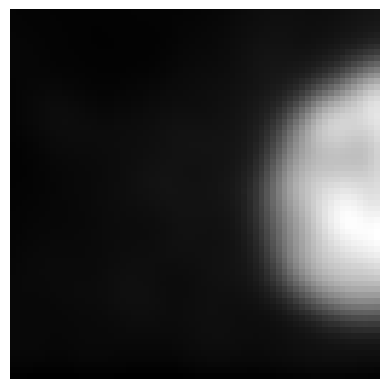

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['image'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'physical_pixel_sizes': '[None, None, None]',
 'reader': "{'extension': 'png', 'imageio_read_mode': '?'}",
 'resolution_level_dims': '{0: [512, 512]}',
 'resolution_levels': '[

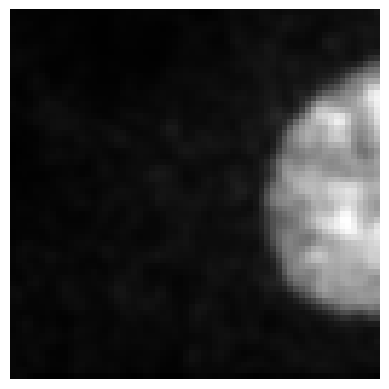

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'physical_pixel_sizes': '[None, None, None]',
 'reader': "{'extension': 'png', 'imageio_read_mode': '?'}",
 'resolution_level_dims': '{0: [512, 512]}',
 'resolution_levels': '[

In [ ]:
affine

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset_random',
    colmap=colmap, 
    patch_transforms=transforms_list, 
    image_splitter=RandomPatchSplitter(patch_size, num_patches=3), 
    )


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 26.64it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 29.51it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset_random.h5
Patch information saved to CSV: ./_test_tfms/patches_dataset_random.csv


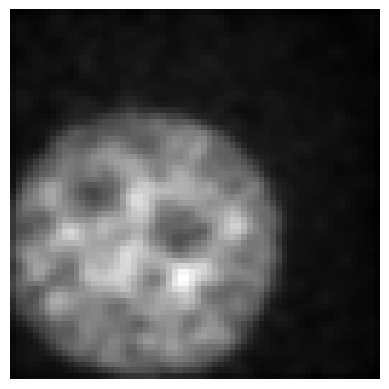

In [ ]:
file_path = output_folder + '/patches_dataset_random.h5/' + pd.read_csv('./_test_tfms/patches_dataset_random.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510006.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': "{'GaussianSmoothd': {'__class__': 'GaussianSmoothd', 'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}",
 'physi

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()